<a href="https://colab.research.google.com/github/jose-esquivel-dev/Analitica_de_Datos/blob/main/U2/Practica_4/AD_U2_Practica4_RegresionLog_MiaLlanas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


**Curso: modelos de aprendizaje**

**UNIDAD 2**


---

*   NOMBRE: Mia Llanas Hernández
*   NO CONTROL: 22111513



In [24]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
import os
DIR = "/content/drive/MyDrive/Análitica de Datos "
os.chdir(DIR)

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Librerías para preprocesamiento e ing de características
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder,StandardScaler, OrdinalEncoder,FunctionTransformer

# Librerías para la canalización
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.pipeline import make_pipeline

# Librerías para la regresión
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, mean_squared_error, r2_score, confusion_matrix, precision_score,recall_score,accuracy_score
from sklearn.decomposition import PCA

from sklearn.preprocessing import PolynomialFeatures

---

## **<font color=" #895cf9">Explica brevemente el uso de las librerias del segmento de codigo anterior, haciendo uso de la siguiente tabla</font>**


| Library | Explanation  |
|----------|--------------|
|**import pandas as np**| Libreria para la manipulación de datos	|
|**import numpy as np**|Libreria para la manipulación de datos	|
|**import matplotlib.pyplot as plt**| Libreria para visualización |
|**import seaborn as sns** | Libreria para visualización |
|**from sklearn.impute import SimpleImputer** |  Sirve para rellenar los datos faltantes, Cuando tienes datos con valores nulos NaN, permite remplazarlos con mean, median, most_frecuent, constant|
|**from sklearn.preprocessing import MinMaxScaler** | Escala y normaliza las características numéricas para que sus valores queden dentro de un rango específico, generalmente entre 0 y 1.|
|**from sklearn.preprocessing import OneHotEncoder** | Convierte variables categóricas en columnas binarias independientes para que los algoritmos numéricos puedan procesarlas. |
|**from sklearn.preprocessing import StandardScaler** |Estandariza las características restando la media y dividiendo entre la desviación estándar, logrando que los datos tengan una media de 0 y una varianza de 1. |
|**from sklearn.preprocessing import OrdinalEncoder** |Transforma variables categóricas que tienen un orden o jerarquía lógica en valores numéricos enteros secuenciales. |
|**from sklearn.preprocessing import FunctionTransformer** |Permite aplicar funciones matemáticas personalizadas a los datos dentro de un flujo estructurado de preprocesamiento. |
|**from sklearn.compose import ColumnTransformer, make_column_selector** | Facilita la selección automática de columnas dentro de un DataFrame según su tipo de datos.|
|**from sklearn.pipeline import make_pipeline** |Permite encadenar múltiples pasos de procesamiento y modelado en una sola estructura secuencial, evitando errores comunes como la fuga de datos. |
|**from sklearn.linear_model import LinearRegression**|Es el algoritmo básico de Machine Learning para realizar regresión lineal, buscando la línea de mejor ajuste para predecir un valor continuo.|
|**from sklearn.linear_model import LogisticRegression** |A pesar de su nombre, es un algoritmo utilizado para tareas de clasificación.|
|**from sklearn.pipeline import make_pipeline**|Permite encadenar múltiples pasos de procesamiento y modelado en una sola estructura secuencial, evitando errores comunes como la fuga de datos. |
|**from sklearn.metrics import mean_square_error, mean_square_error**|Calcula el error cuadrático medio para medir qué tan alejadas están las predicciones del modelo de los valores reales.  |
|**from sklearn.metrics import mean_square_error, r2_score**|  Calcula el coeficiente de determinación que mide qué tan bien el modelo explica la variabilidad de los datos. |
|**from sklearn.metrics import mean_square_error, confusion_matrix**| Crea una matriz de confusión para evaluar el rendimiento de un modelo de clasificación comparando aciertos y errores. |
|**from sklearn.metrics import mean_square_error, precision_score, recall_score, acuracy_score**| Son métricas de clasificación para medir la precisión, la sensibilidad y la exactitud global del modelo.|
|**from sklearn.descomposition import PCA**|Significa Análisis de Componentes Principales se usa para la reducción de la dimensionalidad, simplificando conjuntos de datos con muchas variables mientras retiene la mayor cantidad de información posible.|
|**from sklearn.preprocessing import PolynomialFeatures**|Es una herramienta de ingeniería de características que se utiliza para generar características polinómicas e interacciones entre las variables existentes.|







---

In [26]:
#lectura del .csv con pandas
data_df = pd.read_csv('/content/drive/MyDrive/Análitica de Datos /data.csv')

# **Parte 1**. EDA

Haz que el `id` sea el índice del dataframe y efectúa una exploración inicial de los datos a través de:

In [27]:
#utilice funcion .set_index()
#Guarde los cambios con inplace=True

#-----------------------------------------------------
#Escriba su codigo
data_df.set_index('id',inplace=True)


#-----------------------------------------------------

#-----------------------------------------------------


In [28]:
data_df

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
id,,,,,,,,,,,,,,,,,,,,,
842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820




1a) Estadísticas descriptivas para todas las variables del dataframe.

In [29]:
#.describe para variables Numericas
#-----------------------------------------------------
data_df.describe()
#-----------------------------------------------------

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [30]:
#.describe() para variable categoricas
#-----------------------------------------------------
data_df.describe(include=['O'])
#-----------------------------------------------------

,diagnosis
count,569
unique,2
top,B
freq,357


1b) Valores únicos por variable para identificar posibles variables categóricas.

In [31]:
# Se hace una lista de variables numéricas y otra de categóricas.
#-----------------------------------------------------
num_cols = data_df.select_dtypes(include=np.number).columns.tolist() #para variables numericas
cat_cols = data_df.select_dtypes(exclude=np.number).columns.tolist() #para variables Categoricas
#-----------------------------------------------------

In [32]:
# Recuento de cada categoría única en las variables categóricas
for col in cat_cols:
    print(data_df[col].value_counts())
    print("-" * 40)

diagnosis
B    357
M    212
Name: count, dtype: int64
----------------------------------------


In [33]:
# Recuento de cada categoría única en las variables categóricas


1c) Búsqueda de valores faltantes.

In [34]:
#Explica cada linea de codigo
print('Número valores faltantes: ') #Imprime un encabezado en pantalla para indicar que se mostrará el reporte de datos faltantes.
for col in data_df.columns: #Inicia un bucle que recorrera una por una todas las columnas que conforman el data frame.
  valor=sum(data_df[col].isna()) #Evalua cada elemento de la columna actual para detectar valores nulos y luego suma cuántos verdaderos encontro para obtener el total absoluto de faltantes.
  porcentaje=data_df[col].isna().mean()*100 #Calcula el promedio de valores nulos en la columna y lo multiplica por 100 para obtener el porcentaje exacto que representan esos datos faltantes respecto al total de filas.
  print('{}:{}: porcentaje :{}'.format(col,valor,porcentaje)) #Muestra de manera formateada en la consola el nombre de la columna la cantidad absoluta de nulos y el porcentaje de ausencia correspondiente.

Número valores faltantes: 
diagnosis:0: porcentaje :0.0
radius_mean:0: porcentaje :0.0
texture_mean:0: porcentaje :0.0
perimeter_mean:0: porcentaje :0.0
area_mean:0: porcentaje :0.0
smoothness_mean:0: porcentaje :0.0
compactness_mean:0: porcentaje :0.0
concavity_mean:0: porcentaje :0.0
concave points_mean:0: porcentaje :0.0
symmetry_mean:0: porcentaje :0.0
fractal_dimension_mean:0: porcentaje :0.0
radius_se:0: porcentaje :0.0
texture_se:0: porcentaje :0.0
perimeter_se:0: porcentaje :0.0
area_se:0: porcentaje :0.0
smoothness_se:0: porcentaje :0.0
compactness_se:0: porcentaje :0.0
concavity_se:0: porcentaje :0.0
concave points_se:0: porcentaje :0.0
symmetry_se:0: porcentaje :0.0
fractal_dimension_se:0: porcentaje :0.0
radius_worst:0: porcentaje :0.0
texture_worst:0: porcentaje :0.0
perimeter_worst:0: porcentaje :0.0
area_worst:0: porcentaje :0.0
smoothness_worst:0: porcentaje :0.0
compactness_worst:0: porcentaje :0.0
concavity_worst:0: porcentaje :0.0
concave points_worst:0: porcentaje :

1d) Diagrama de barras para determinar la frecuencia de los diagnósticos (cantidad de observaciones con resultado benigno y maligno)

/tmp/ipykernel_2030/2561921228.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data_df, x='diagnosis',  palette='Set2')


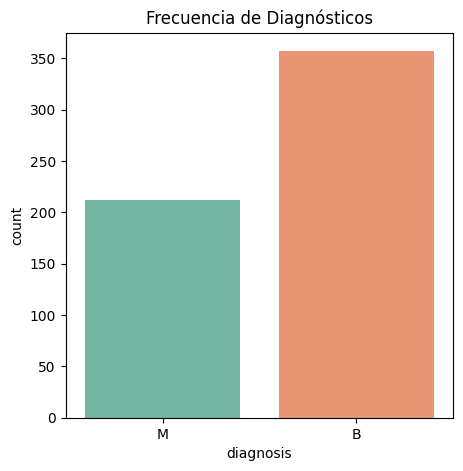

In [35]:
#utilice sns.countplot()
#-----------------------------------------------------
plt.figure(figsize=(5,5))
sns.countplot(data=data_df, x='diagnosis',  palette='Set2')
plt.title('Frecuencia de Diagnósticos')
plt.show()
#-----------------------------------------------------

2. Como hay tres valores relacionados con la misma característica (`mean`, `se` y `worst`) es muy probable que exista multicolinealidad en el conjunto.

La multicolinealidad en regresión es una condición que ocurre cuando algunas variables predictoras están fuertemente correlacionadas entre sí, de tal manera que si se incluyen simultáneamente en un modelo, impiden explicar de manera correcta el efecto que cada una tiene sobre la variable respuesta. Existen muchas formas de analizar si hay colinealidad en los modelos, una de ellas es el alto coeficiente de correlación entre variables.

Para observar este efecto, elabora un mapa de calor que cuantifique la correlación de las variables numéricas en el dataframe.

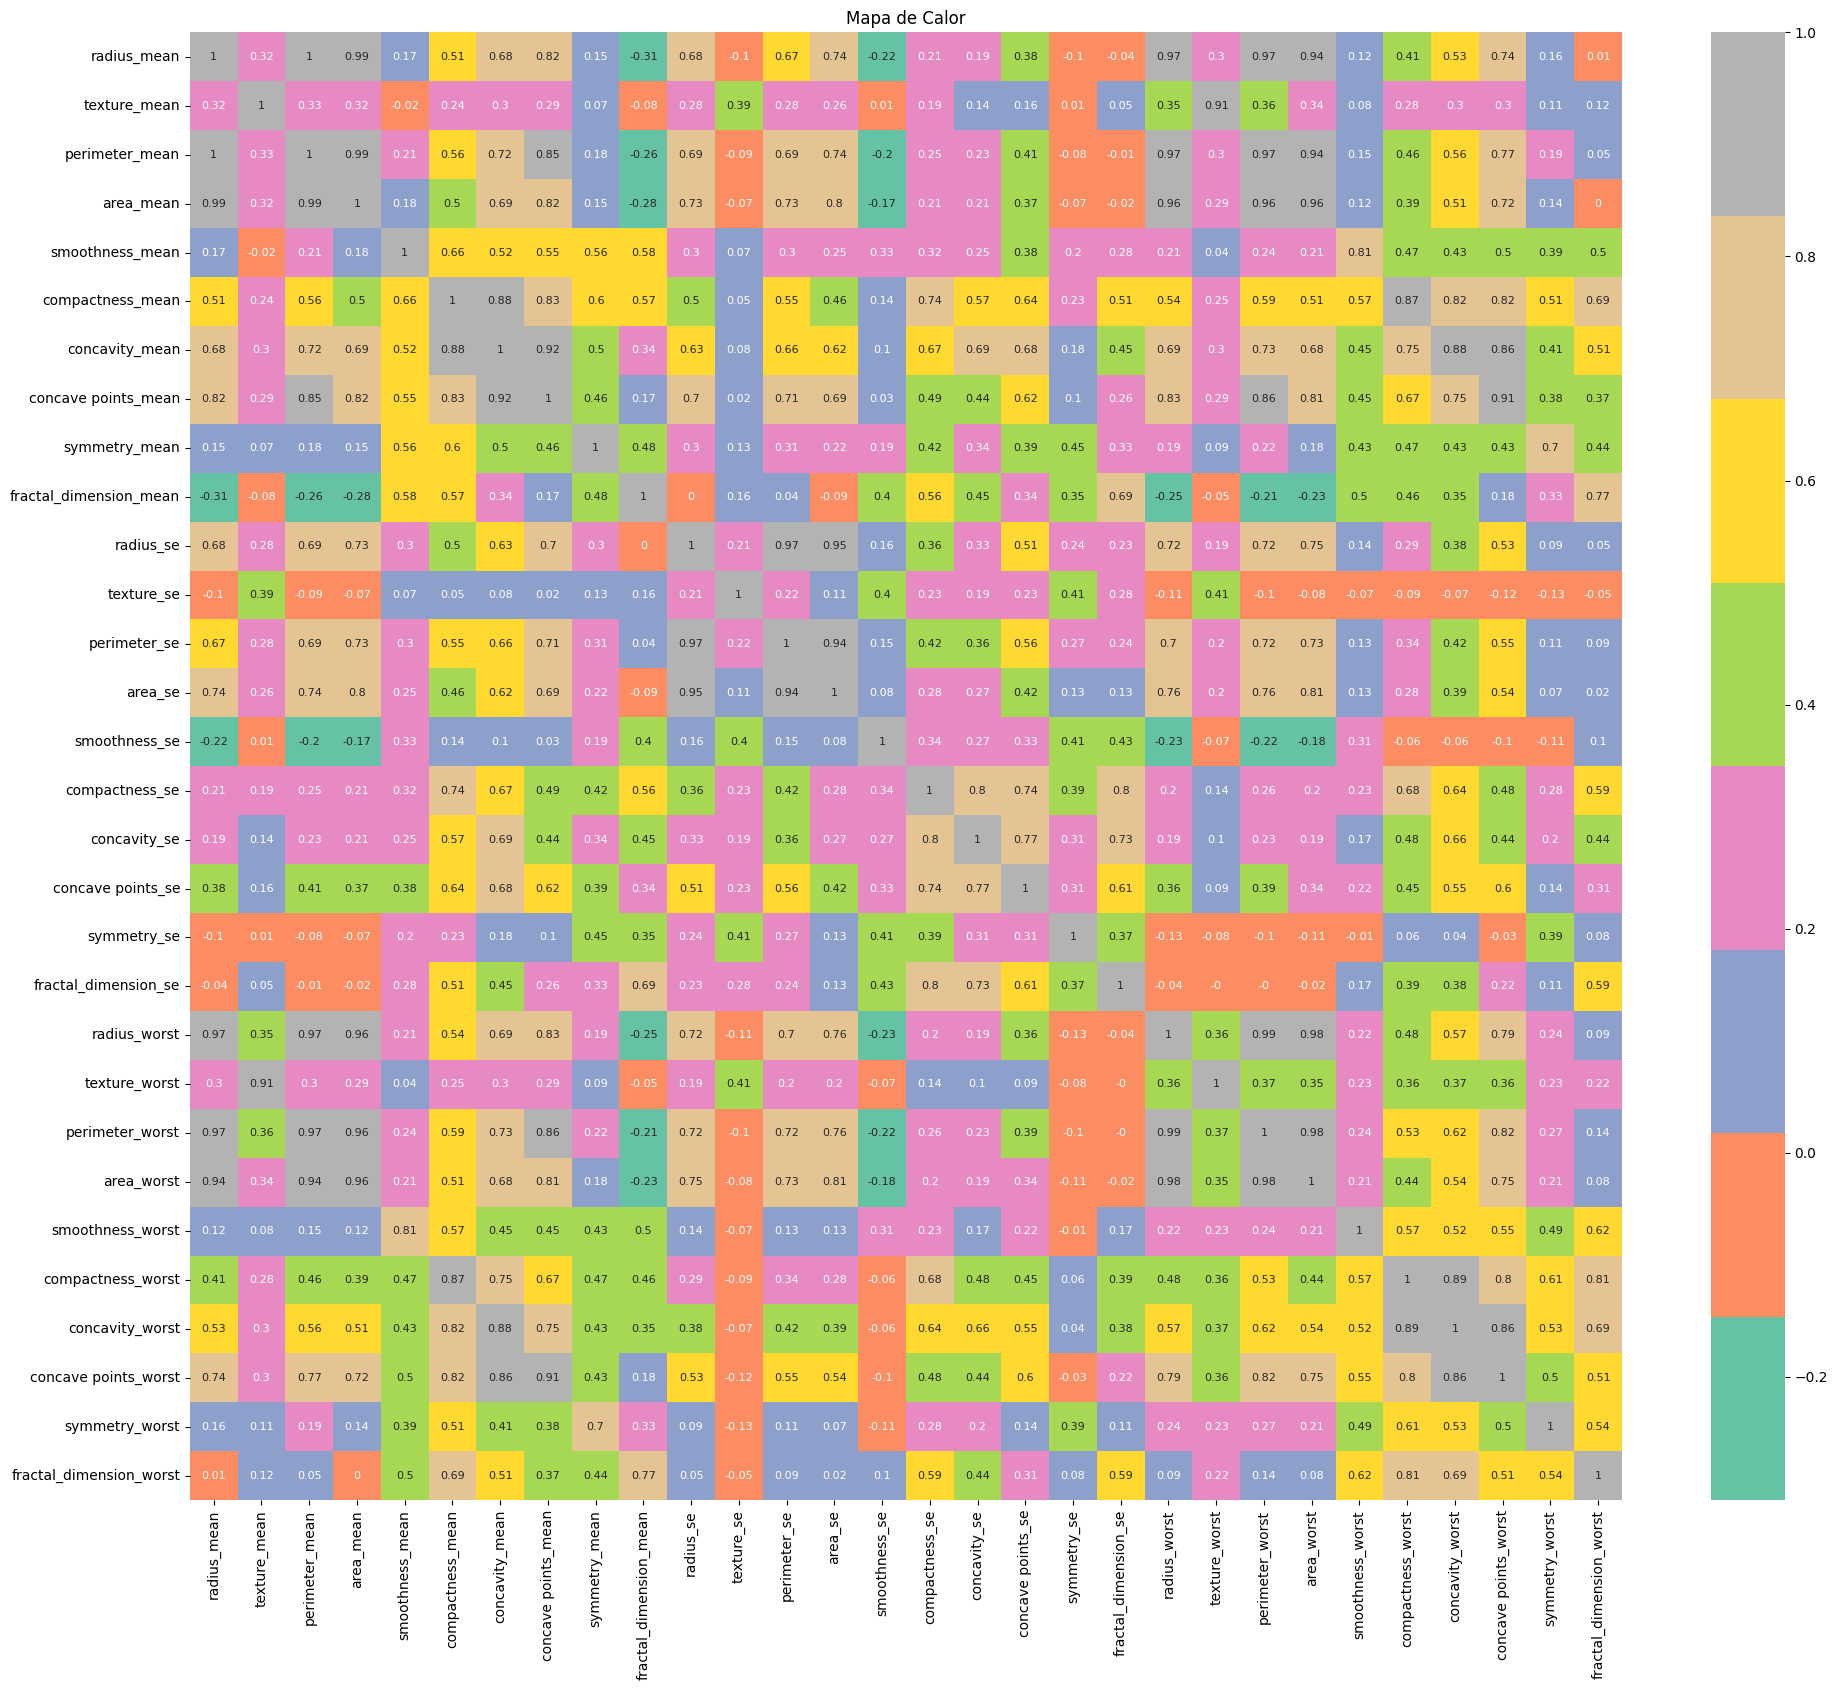

In [36]:
numeric_df = data_df.select_dtypes(include=[float, int])

#-----------------------------------------------------
plt.figure(figsize=(20, 17))
sns.heatmap(round(numeric_df.corr(numeric_only=True), 2), annot=True, cmap='Set2', annot_kws={'size': 8})
plt.title('Mapa de Calor')
plt.tight_layout()
#-----------------------------------------------------

Si te fijas en los valores de correlación entre las variables `_mean` y `_worst` es evidente la multicolinearidad.

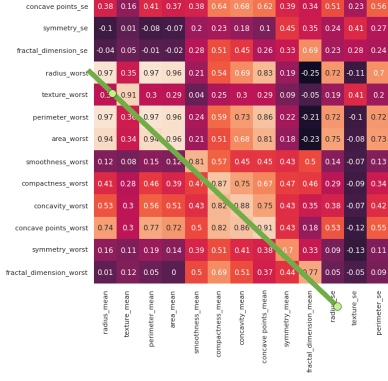

Por ejemplo, la columna `radius_mean` tiene una correlación de 0.97 con la columna `radius_worst`. Esto es algo inevitable, porque las columnas "peores" son esencialmente solo un subconjunto de las columnas "medias".

Para solucionar el problema numérico de la multicolinealidad, tradicionalmente se recurre a eliminar variables o efectuar análisis de componentes principales (PCA) con las `X`’s y usar los componentes como variables independientes en un modelo final.

Conduciremos esta actividad en esos dos sentidos.


# **Parte 2**. Modelo con eliminación de variables altamente correlacionadas  

Elimina las variables altamente correlacionadas:

3a) Ahora que sabes que las variables `_mean` y `_worst` tienen correlación alta, hay que quitar del dataframe un conjunto. Borra las columnas `_worst`.

In [37]:
#-----------------------------------------------------
#Elimine TODAS las columnas _worst
#para borrar las columnas _worst
cols_a_conservar = [col for col in data_df.columns if not col.endswith('_worst')]
new_data_df = data_df[cols_a_conservar]

#-----------------------------------------------------
#Convierte new_data_df en Dataframe usando .DataFrame() de la libreria de pandas
new_data_df = pd.DataFrame(new_data_df)
#-----------------------------------------------------

En las graficas de dispersion, los patrones lineales en los diagramas de dispersion se refieren a la relacion entre dos variables que sigue una tendencia aproximadamente en linea recta, ya sea en direccion ascendente o descentende

* **Patron lineal positivo**: Si la linea se inclina hacia arriba (de izquierda a derecha), indica que hay una relacion directa entre las variables: cuando la variable aumenta, la otra tambien lo hace, es decir, CORRELACION POSITIVA

* **Patron lineal negativo**: si la linea se incluna hacia abajo (de izquierda a derecha), indica quue cuando una variable aumenta, la otra disminuye, es decir, CORRELACION NEGATIVA

* **Patron lineal perfecto**, si los puntos siguen una linea recta perfecta, la relacion entre las variables es exactamente lineal, sin desviaciones.


3b. Entre las variables `_mean`, identifica patrones lineales con diagramas de dispersión usando:

    sns.pairplot(data=nuevo_df[['radius_mean',
        'texture_mean',
        'perimeter_mean',
        'area_mean',
        'smoothness_mean',
        'compactness_mean',
        'concavity_mean',
        'concave points_mean',
        'symmetry_mean',
        'fractal_dimension_mean']])



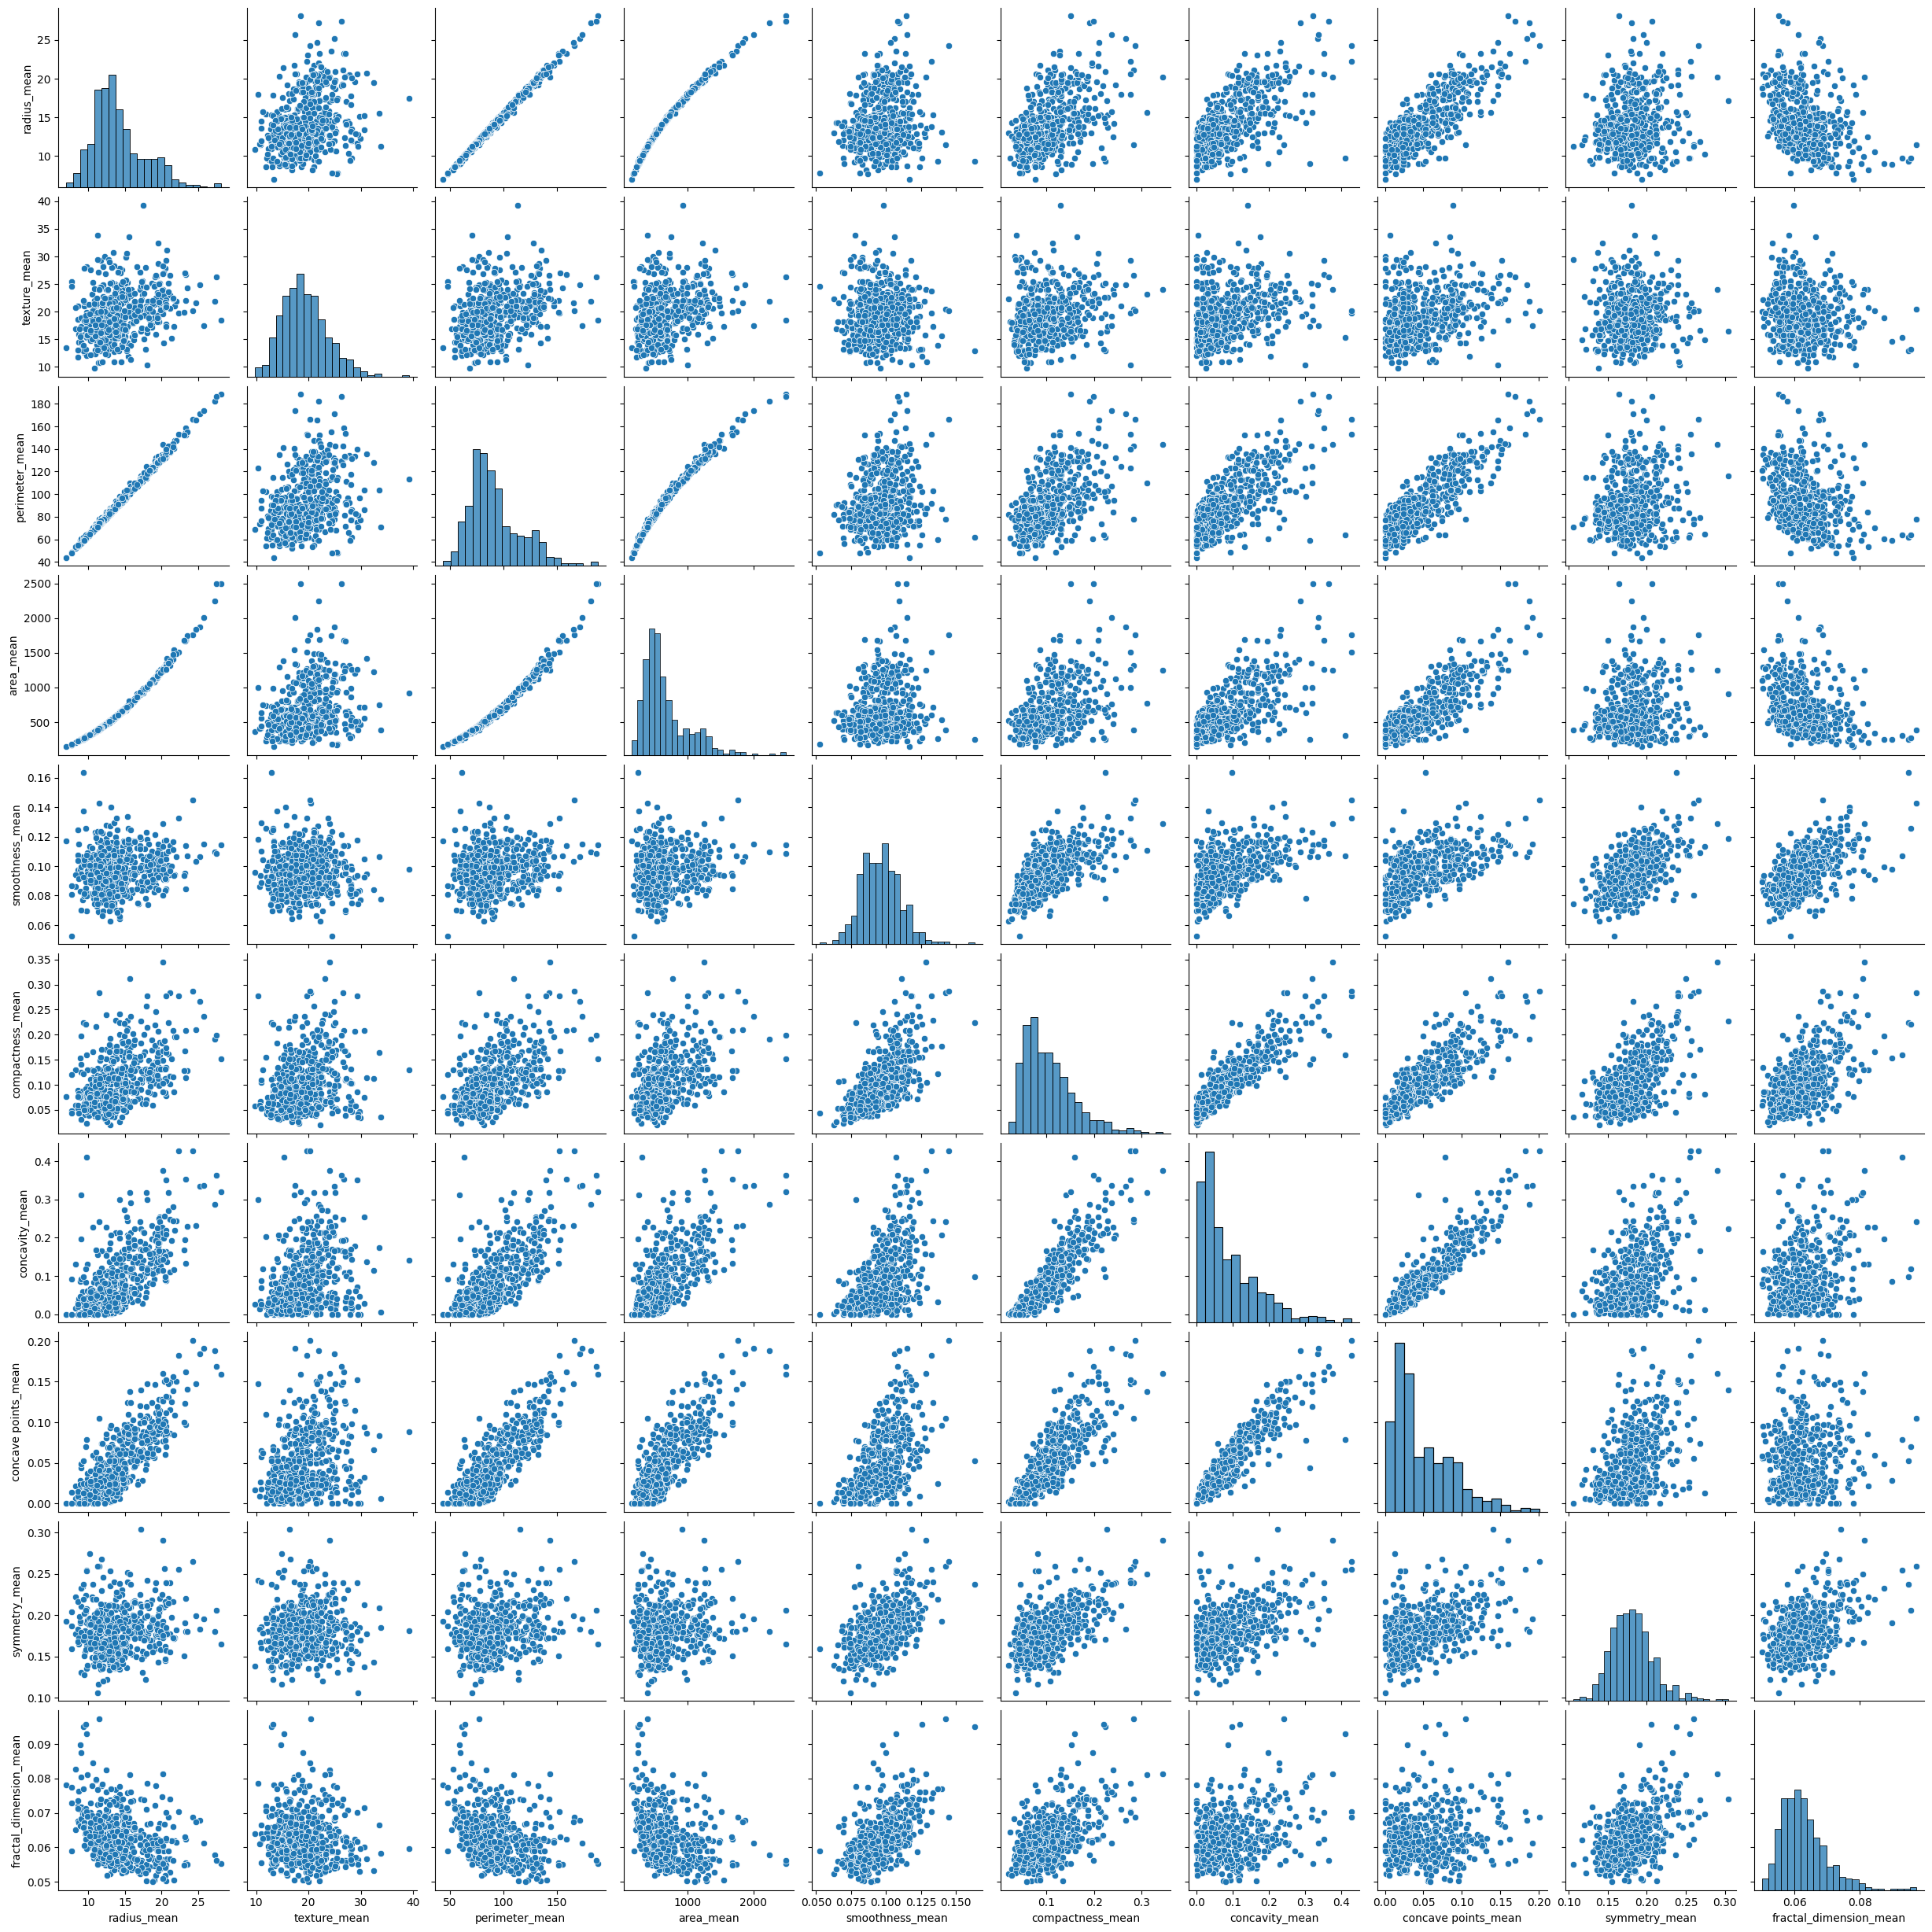

In [38]:
#-----------------------------------------------------
#Pega aqui el codigo sns.pairplot()
sns.pairplot(data=data_df[['radius_mean',
    'texture_mean',
    'perimeter_mean',
    'area_mean',
    'smoothness_mean',
    'compactness_mean',
    'concavity_mean',
    'concave points_mean',
    'symmetry_mean',
    'fractal_dimension_mean']])
#-----------------------------------------------------

De la matriz podrás observar relaciones lineales bastante evidentes entre:


*   `radius_mean`, `perimeter_mean` y `area_mean`
*   `compactness_mean`, `concavity_mean`, `concave_points_mean`

Sabemos que el perímetro y el área de un círculo, se calculan a partir del radio. Entonces, la relación entre las primeras tres variables es muy clara para nosotros.

3c) Elabora otro mapa de calor confirmar con los valores de correlación.


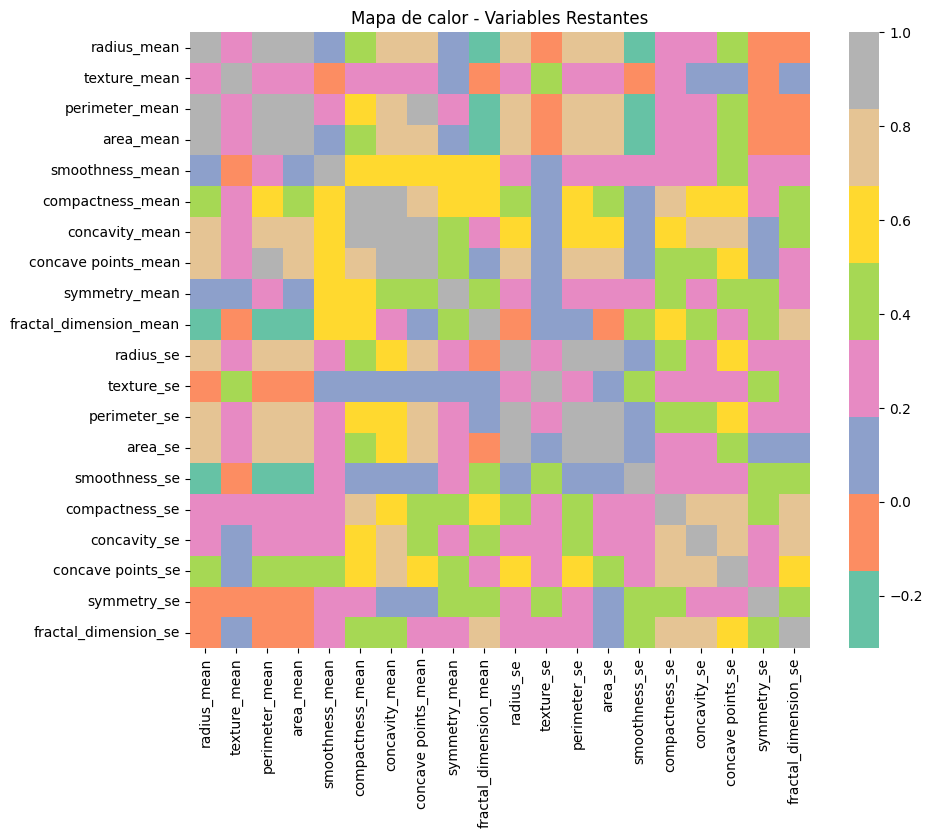

In [39]:
#-----------------------------------------------------
#Agrega codigo para el mapa de calor
plt.figure(figsize=(10, 8))
sns.heatmap(new_data_df.select_dtypes(include=[np.number]).corr(), annot=False, cmap='Set2')
plt.title('Mapa de calor - Variables Restantes')
plt.show()
#-----------------------------------------------------

3d) Después de observar los valores, nos quedaremos con sólo una variable de cada trío: `radius_mean` y `compactness_mean`. Elimina las restantes, no sólo del conjunto `_mean`, sino también de `_se`.

In [40]:

#-----------------------------------------------------
#escriba TODAS las columnas que seran eliminadas
columnas_a_eliminar=[]
#-----------------------------------------------------



#-----------------------------------------------------
#Convierte new_data_df en Dataframe usando .DataFrame() de la libreria de pandas
new_data_df=new_data_df.drop(columns=columnas_a_eliminar) #complete linea codigo
new_data_df
#-----------------------------------------------------


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se
id,,,,,,,,,,,,,,,,,,,,,
842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,...,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193
842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,...,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532
84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,...,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571
84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,...,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208
84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,...,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,...,1.1760,1.2560,7.673,158.70,0.010300,0.02891,0.05198,0.02454,0.01114,0.004239
926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,...,0.7655,2.4630,5.203,99.04,0.005769,0.02423,0.03950,0.01678,0.01898,0.002498
926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,...,0.4564,1.0750,3.425,48.55,0.005903,0.03731,0.04730,0.01557,0.01318,0.003892


Observa la distribución de las variables resultantes (deben ser 12, sin contar la columna de indice):

4a) Utilizando histogramas. Guarda en una variable (`skew_cols`) las que tengan marcado sesgo positivo. Para dar seguridad a tu selección, elige aquellas cuyo resultado de aplicar la función `skew()` sea mayor a 1.

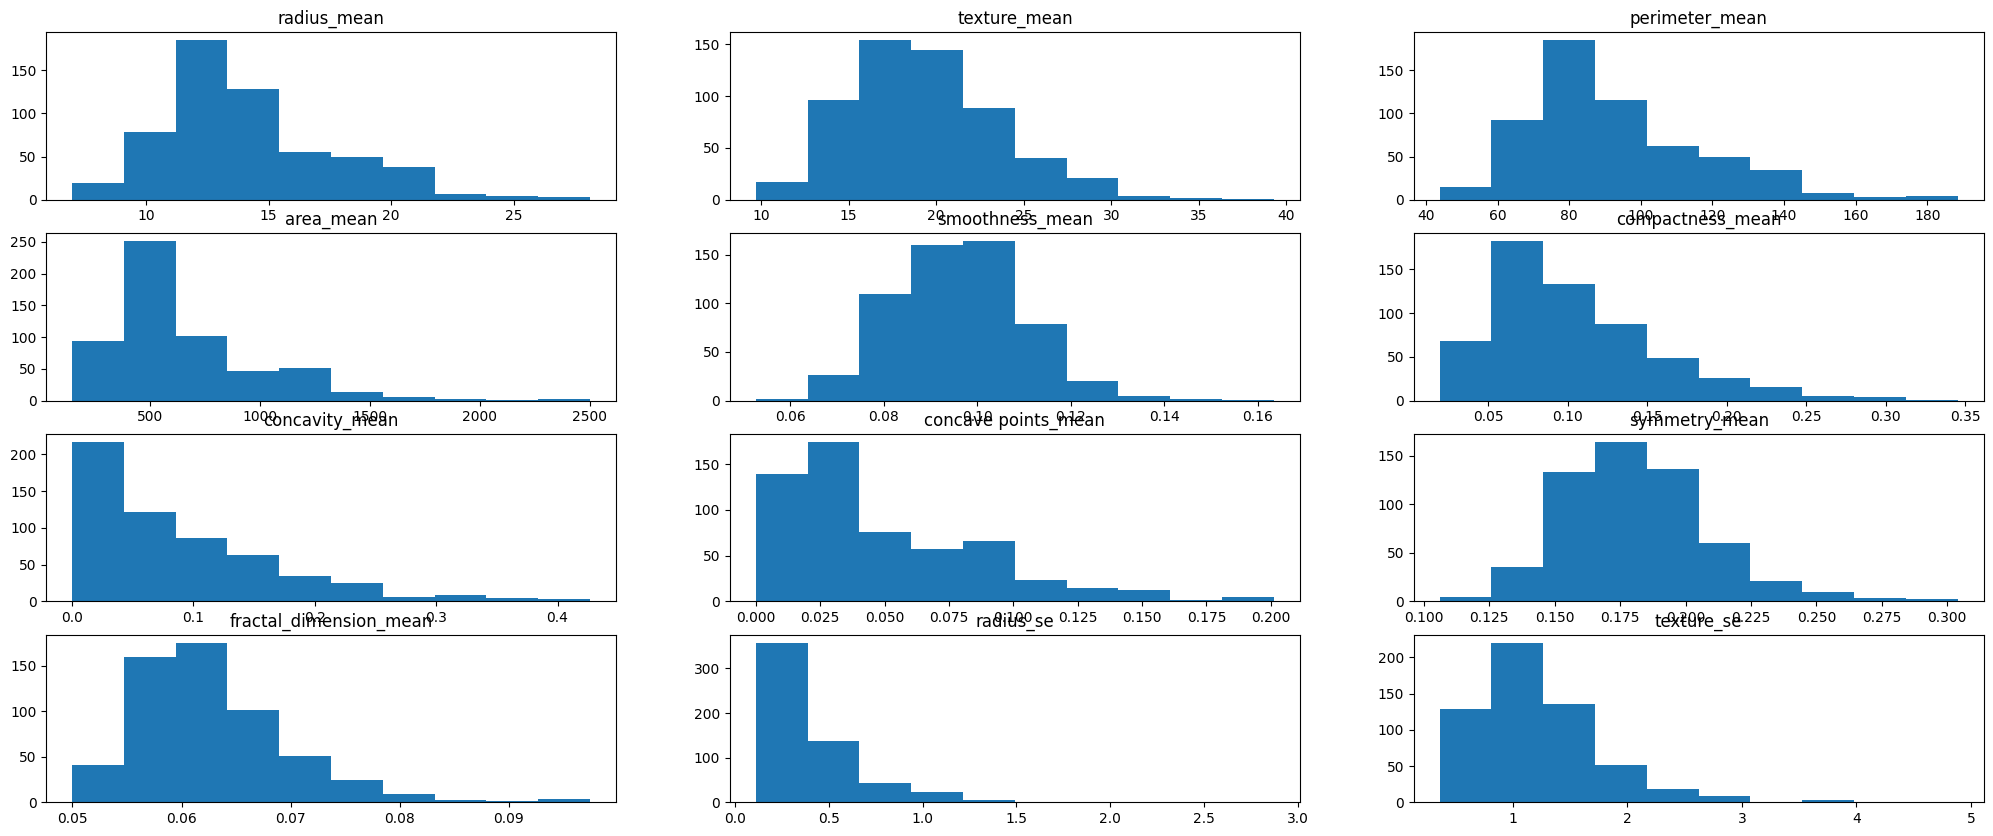

In [41]:
#EXPLICA CADA LINEA DE CODIGO
skew_cols_df=pd.DataFrame() #Crea un DataFrame vacío llamado skew_cols_df que va a utilizar para almacenar de forma temporal las columnas que presenten un alto sesgo.
fig, axes =plt.subplots(4,3, figsize=(25,10)) #25 es el ancho, 10 altura   ---- 4,3 significa que seran  4 filas y 3 columnas
axes = axes.ravel()  #Convierte la matriz bidimensional de ejes en un arreglo plano unidimensional para poder recorrerlos de manera sencilla uno por uno dentro de un bucle.
num_cols = new_data_df.select_dtypes(include=np.number).columns.tolist()  #Filtra el DataFrame new_data_df para extraer únicamente las columnas de tipo numérico y las convierte en una lista de Python llamada num_cols.


for col, ax in zip (num_cols, axes):  #Inicia un bucle for que empareja y recorre al mismo tiempo cada nombre de columna numérica con su respectivo espacio gráfico asignado.
  ax.hist(new_data_df[col]) #Dibuja el histograma correspondiente a los datos de la columna actual dentro del gráfico asignado.
  ax.set(title = f'{col}', xlabel=None) #Asigna un título automático a cada subgráfico con el nombre de la variable y elimina la etiqueta por defecto del eje X para mejorar la estética visual.
  if new_data_df[col].skew()>1 : skew_cols_df[col] =new_data_df[col] #Calcula la asimetría de la columna; si el valor es mayor a 1, copia y almacena esa columna dentro del DataFrame skew_cols_df.

skew_cols = skew_cols_df.columns.values #Extrae y guarda en un arreglo los nombres finales de todas las columnas que cumplieron con la condición de tener un sesgo superior a 1.



In [42]:
skew_cols

array(['area_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'fractal_dimension_mean', 'radius_se',
       'texture_se'], dtype=object)

4b) Dibujando box plots de todas las variables. Guarda en una variable (`scale_cols`) aquellas que no se encuentren en el intervalo [0,1]


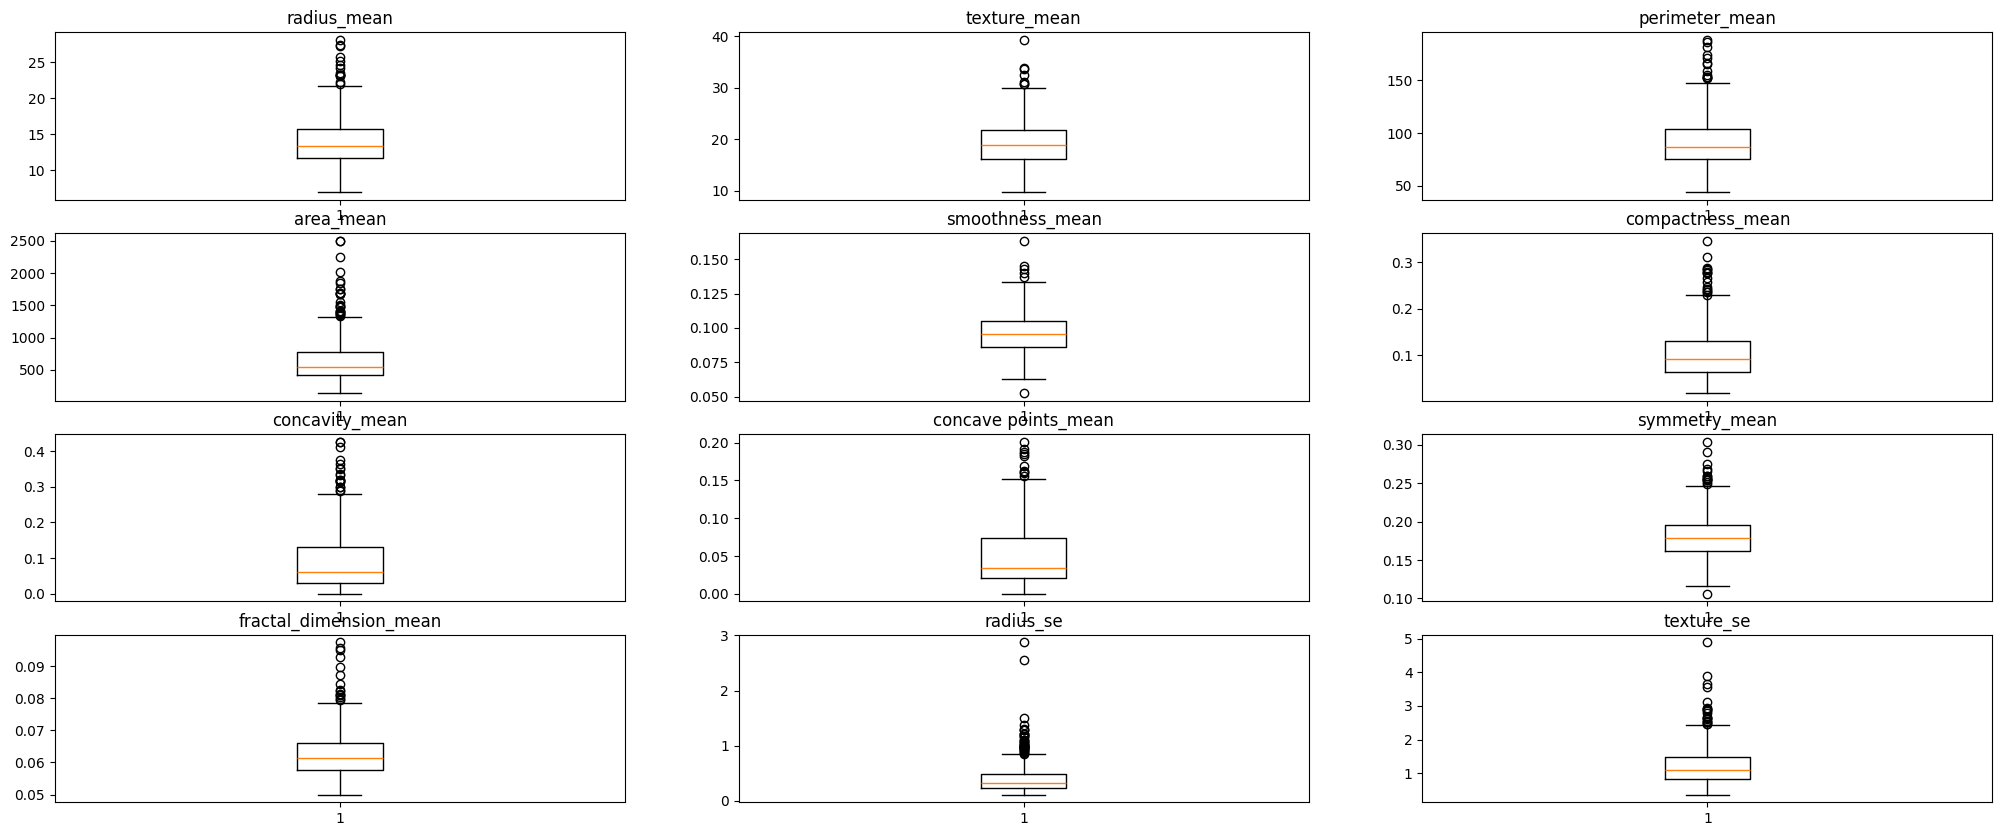

In [43]:
scale_cols_df=pd.DataFrame()
fig, axes = plt.subplots(4,3, figsize=(25,10))
axes = axes.ravel()

#-----------------------------------------------------
for col, ax in zip(new_data_df[num_cols], axes):

  ax.boxplot(new_data_df[col]) #COMPLETA LINEA DE CODIGO
  ax.set_title(f'{col}')

  #COMPLETA EL IF
  if new_data_df[col].max() < 1 and new_data_df[col].min() >= 0:
     scale_cols_df[col] = new_data_df[col]
#-----------------------------------------------------

scale_cols = scale_cols_df.columns.values

In [44]:
scale_cols

array(['smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean'],
      dtype=object)

Con todo el análisis anterior, estamos listos para generar un modelo *baseline* denominado `logr_model`. Para ello:

5a) Vuelve a leer el contenido del archivo, haz que el `id` sea el índice y separa las variables del dataframe: en `X` coloca los predictores y en `y` la variable de respuesta o salida (`diagnosis`). Divide el conjunto en entrenamiento y prueba (80:20) considerando el parámetro `random_state` con el valor de 1.

In [45]:
data_df = pd.read_csv('/content/drive/MyDrive/Análitica de Datos /data.csv')

#-----------------------------------------------------
#AGREGA LINEA DE CODIGO PARA CONVERTIR COLUMNA "ID" EN INDICE
data_df.set_index('id',inplace=True)

# Separa las variables predictoras (X) y la variable de respuesta (y)
X = data_df.drop(columns=['diagnosis'])
y = data_df['diagnosis']

# Divide el conjunto en entrenamiento y prueba (80% entrenamiento, 20% prueba)
from sklearn.model_selection import train_test_split
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.2, random_state=1)



In [46]:
X = data_df.copy() #Se crea copia del df


#-----------------------------------------------------
#                                  COMPLETA CODIGO
# se elimina variable Categorica "diagnosis" de (X), debido a se sera utilizada como variable de salida (y)
#-----------------------------------------------------
#Especifique la columna que desea eliminar
#Utilice el parametro axis=1, permitira eliminar la columna
#Guarde los cambios agregando el parametro inplace=True

X.drop('diagnosis', axis=1, inplace=True) #Caracteristica / variable Entrada
#-----------------------------------------------------

#-----------------------------------------------------
y = data_df['diagnosis'] #Objetivo /Variable salida
#-----------------------------------------------------

In [47]:
#Libreria necesaria para realizar la particion del conjunto de datos
from sklearn.model_selection import train_test_split


# Se divide el conjunto en entrenamiento y prueba (80:20), es decir, 80% para Entrenamiento (train) y 20% para Prueba (test)
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.2, random_state=1)



5b) Prepara un transformador, denominado `preprocessing`, para borrar las columnas altamente correlacionadas (las 18 variables que se determinaron en los ejercicios previos) Asegúrate de incluir el parámetro `remainder='passthrough'` para mantener el resto de las variables.

In [48]:
#EXPLIQUE CADA LINEA DE CODIGO
columnas_a_eliminar=['radius_worst','texture_worst','perimeter_worst','area_worst','smoothness_worst','compactness_worst','concavity_worst','concave points_worst','symmetry_worst','fractal_dimension_worst','perimeter_mean','area_mean','concavity_mean','concave points_mean','perimeter_se','area_se','concavity_se','concave points_se']
#Crea una lista en Python que almacena los nombres exactos de todas las columnas que se han decidido descartar del dataa frame.
preprocessing = ColumnTransformer([   #Inicializa y crea un objeto
    ('num', 'drop', columnas_a_eliminar)]  #Define una regla dentro del transformador nombrada como num.
   ,remainder='passthrough') #Configura el parámetro remainder con la opción passthrough


5c) Entrena el modelo `logr_model` con el transformador `preprocessing` y  regresión logística.

Como la salida `y` está en términos de las etiquetas `'B'` y `'M'`, en lugar de 0 y 1, para evaluar el modelo en el conjunto de prueba deberás especificar la clase positiva. En el caso de la matriz de confusión, indica el orden de las etiquetas con `labels=['B','M']`, porque `'B'` es la clase negativa (ésta se especifica primero) y `'M'` la positiva. Para las métricas de *recall* y *precision*, utiliza el parámetro `pos_label='M'`. Como *accuracy* ocupa la suma de ambas clases y el total de las observaciones, no requiere ninguna especificación. Si quisieras omitir estos parámetros, tendrías que sustituir `'B'` por 0 y `'M'` por 1, previo a la construcción del modelo.

In [49]:
#EXPLIQUE CADA LINEA DE CODIGO

logr_model=make_pipeline(preprocessing, LogisticRegression())  #Crea un flujo de trabajo encadenado llamado logr_model que aplica primero el transformador de preprocesamiento y luego entrena directamente un modelo de clasificación por regresión logistica.
logr_model.fit(Xtrain,ytrain) #Entrena el modelo completo utilizando los datos del conjunto de entrenamiento.
predictions=logr_model.predict(Xtest) #Utiliza el modelo ya entrenado para generar predicciones sobre el conjunto de prueba.


print('matriz de confusion 1:\n',confusion_matrix(ytest,predictions,labels=['B','M'])) #Calcula e imprime la matriz de confusión comparando los resultados reales con las predicciones.
print('recall    :\t',recall_score(ytest,predictions,pos_label='M')) # Calcula e imprime la métrica de recall
print('precision :\t',precision_score(ytest,predictions,pos_label='M')) #Calcula e imprime la precisión del modelo tambien enfocada en la clase positiva M.
print('accurancy :\t',accuracy_score(ytest,predictions)) #Calcula e imprime la exactitud


matriz de confusion 1:
 [[68  4]
 [10 32]]
recall    :	 0.7619047619047619
precision :	 0.8888888888888888
accurancy :	 0.8771929824561403


<font color=" ORANGE">INTERPRETE LOS RESULTADOS OBTENIDOS EN MATRIZ DE CONFUSION Y METRICAS

1. Interpretación de la Matriz de Confusión

    Verdaderos Negativos: Casos que eran realmente benignos 'B' y que el modelo clasificó correctamente como benignos.

    Falsos Positivos: Casos que eran benignos 'B', pero el modelo predijo erróneamente que eran malignos 'M'. En medicina, esto representa una falsa alarma.

    Falsos Negativos: Casos que eran realmente malignos 'M', pero el modelo clasificó erróneamente como benignos 'B'. Este es el error más crítico en diagnósticos médicos, ya que un paciente enfermo no es detectado a tiempo.

    Verdaderos Positivos: Casos que eran realmente malignos 'M' y que el modelo detectó y clasificó correctamente como malignos.

2. Interpretación de las Métricas

    Recall:
    Mide la capacidad del modelo para encontrar todos los casos reales de cáncer maligno 'M'. Un recall alto significa que el modelo logró capturar a la gran mayoría de los pacientes enfermos, dejando muy pocos falsos negativos sin detectar.

    Precision:
    Mide la fiabilidad de las predicciones positivas del modelo. De todos los diagnósticos que el modelo marcó como malignos 'M', indica qué porcentaje era realmente correcto. Una alta precisión significa que el modelo genera pocas falsas alarmas.

    Accuracy:
    Representa el porcentaje total de aciertos del modelo en general divididos entre el total de observaciones evaluadas.

Para generar un modelo `logr_model2` con transformación y escalamiento:

6a) Modifica el transformador anterior para, además del borrado de las columnas correlacionadas, aplicar la raíz cuadrada a los predictores con sesgo (previamente almacenados en `skew_cols`) y escalamiento *MinMax* a los predictores con escala mayor a 1 (previamente almacenados en `scale_cols`) Como no todos los predictores serán eliminados o transformados, asegúrate de incluir el parámetro `remainder='passthrough'`

In [50]:
#EXPLIQUE CADA LINEA DE CODIGO
preprocessing2 = ColumnTransformer([ #Crea y define un objeto
    ('num0','drop', columnas_a_eliminar), #Establece la primera regla llamada 'num0',lo que hace eliminar 'drop' todas las columnas que se encuentran listadas en columnas_a_eliminar.
    ('num1',FunctionTransformer(np.sqrt),skew_cols), #Establece la segunda regla llamada 'num1'.
    ('num2',MinMaxScaler(),scale_cols) # Establece la tercera regla llamada 'num2'.
  ],remainder='passthrough') #Configura el parámetro remainder con la opción 'passthrough', lo que le indica al transformador que todas las demás columnas del conjunto de datos que no fueron explícitamente nombradas en las reglas anteriores deben conservarse y pasar intactas sin sufrir ninguna modificación.

6b) Entrena el modelo `logr_model2` con regresión logística, aplicando previamente el transformador modificado. Evalúa el modelo en el conjunto de prueba con las mismas métricas.

In [51]:
logr_model2 = make_pipeline(preprocessing2, LogisticRegression(max_iter=10000))
logr_model2.fit(Xtrain, ytrain)
predictions2 = logr_model2.predict(Xtest)

print('matriz de confusion 2:\n', confusion_matrix(ytest, predictions2, labels=['B', 'M']))
print('recall    :\t', recall_score(ytest, predictions2, pos_label='M'))
print('precision :\t', precision_score(ytest, predictions2, pos_label='M'))
print('accurancy :\t', accuracy_score(ytest, predictions2))


matriz de confusion 2:
 [[68  4]
 [ 7 35]]
recall    :	 0.8333333333333334
precision :	 0.8974358974358975
accurancy :	 0.9035087719298246


<font color=" ORANGE">INTERPRETE LOS RESULTADOS OBTENIDOS EN MATRIZ DE CONFUSION Y METRICAS

<font color=" PINK">1. Interpretación de la Matriz de Confusión

-Verdaderos Negativos 68: Casos realmente benignos 'B' que el modelo identificó de forma correcta como benignos.

-Falsos Positivos 4: Casos benignos 'B' que el modelo clasifico por error como malignos 'M' falsas alarmas.

-Falsos Negativos 7: Casos realmente malignos 'M' que el modelo no detecto y clasifico mal como benignos 'B'.

-Verdaderos Positivos 35: Casos realmente malignos 'M' que el modelo detecto y clasifico como malignos.2.

<font color="PINK">Interpretación de las Métricas

-Recall 83.3 / 0.833: Indica que el modelo logró identificar el 83.3 de todos los casos reales de cáncer maligno, dejando sin detectar a 7 pacientes enfermos .

-Precision 89.7 / 0.897: Muestra que de todas las veces que el modelo diagnosticó un caso como maligno 'M', el 89.7 de las veces estuvo en lo correcto

-Accuracy 90.4 / 0.9035: Representa la exactitud global. Significa que el 90.4 de las predicciones totales realizadas por el modelo fueron correctas.

<font color=" ORANGE">CONCLUSION DE LA PRACTICA

Con estas métricas se concluyo que el uso del segundo preprocesamiento, logró un modelo estable con una exactitud superior al 90%, equilibrando de buena manera la detección de casos malignos sin generar un exceso de falsas alarmas.